## Link Video
### https://drive.google.com/drive/folders/1v1En2xqdBHOVpnJODKBRemMxlZTXfk8y?usp=sharing

# **3. Data Generation using GAN (Modified Model)**

## Import Library

In [ ]:
from zipfile import ZipFile
import tensorflow as tf
import pandas as pd
import numpy as np
import os
import cv2
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.optimizers import Adam
from matplotlib import pyplot as plt
from tensorflow.keras.layers import Input, Dense, Reshape, Conv2D, Conv2DTranspose, Activation, LeakyReLU, Flatten, MaxPooling2D, UpSampling2D, Cropping2D, BatchNormalization
from tensorflow.keras.applications.inception_v3 import InceptionV3, preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras import layers
from tensorflow.keras.layers import Dropout
from tensorflow.keras.preprocessing.image import array_to_img
from scipy.linalg import sqrtm

## Extract File (Because In Colab)

In [ ]:
zip_path = '/content/B_23.zip'
extract_path = '/content/B_23'

with ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

def loadFile(folder_path='/content/B_23', size=(100, 100)):
    images = []
    valid_extensions = ('.jpg', '.png', '.jpeg')

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(valid_extensions):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.resize(img, size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype(np.float32) / 127.5 - 1.0
            images.append(img)

    return np.array(images)

real_images = loadFile()
print("Images loaded:", real_images.shape)

Images loaded: (0,)


## Read Data

In [ ]:
def loadFile(folder_path='B_23', size=(100, 100)):
    images = []
    valid_extensions = ('.jpg', '.png', '.jpeg')

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(valid_extensions):
            img_path = os.path.join(folder_path, filename)
            img = cv2.imread(img_path)
            if img is None:
                continue

            img = cv2.resize(img, size)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = img.astype(np.float32) / 127.5 - 1.0
            images.append(img)

    return np.array(images)

In [ ]:
real_images = loadFile('B_23/B_23', size=(100, 100))

## Show Image

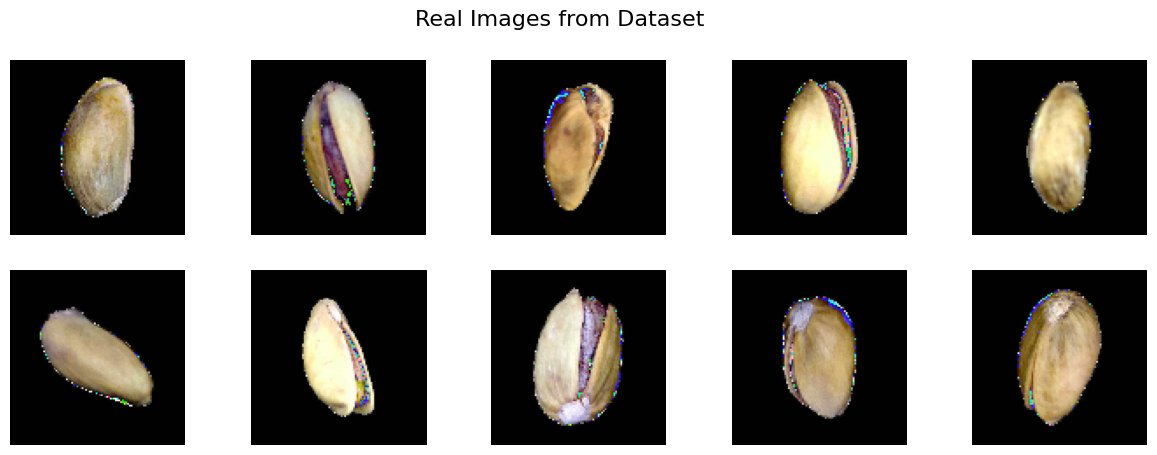

In [ ]:
def plot_real_images(images, num_images=10):
    plt.figure(figsize=(15, 5))
    for i in range(num_images):
        plt.subplot(2, num_images // 2, i + 1)
        plt.imshow((images[i] * 255).astype(np.uint8))
        plt.axis('off')
    plt.suptitle('Real Images from Dataset', fontsize=16)
    plt.show()

plot_real_images(real_images, num_images=10)

## Generator Model

In [ ]:
def build_generator(noise_dim=100):
    model = Sequential()

    model.add(Dense(25 * 25 * 128, input_dim=noise_dim))
    model.add(Reshape((25, 25, 128)))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))

    model.add(UpSampling2D(size=(2, 2)))
    model.add(Conv2D(64, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))

    model.add(UpSampling2D(size=(2, 2)))
    model.add(Conv2D(32, kernel_size=3, padding='same'))
    model.add(BatchNormalization())
    model.add(LeakyReLU(0.2))

    model.add(Conv2D(3, kernel_size=3, padding='same', activation='tanh'))

    return model

modification ReLu into LeakyReLU gives smoother gradients, then the padding we change into 'same' give spatial size consistent, batchnormalization helps stabilize training, and changging the architecture into 25 x 25 x 128 and upsamples to match size of 100 x 100 more cleanly and efficiently

## Discriminator Model

In [ ]:
def build_discriminator(input_shape=(100, 100, 3)):
    model = Sequential()

    model.add(Conv2D(64, kernel_size=4, strides=2, padding='same', input_shape=input_shape))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.3))

    model.add(Conv2D(128, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    model.add(Conv2D(256, kernel_size=4, strides=2, padding='same'))
    model.add(LeakyReLU(0.2))
    model.add(Dropout(0.4))

    model.add(Flatten())
    model.add(Dense(1, activation='sigmoid'))

    return model

changging the ReLU with LeakyReLU same like generator, then adding dropout to prevent discriminator from overfitting, then strides into 2 for learnable weights with padding change into 'same' to maintains spatial shape better during conv layers, then changging the channels into 64 -> 128 -> 256 for more powerful discriminator to handle higher resolution images

In [ ]:
class CustomGAN(tf.keras.Model):
    def __init__(self, discriminator, generator, latent_dim):
        super().__init__()
        self.disc = discriminator
        self.gen = generator
        self.latent_dim = latent_dim

    def compile(self, disc_optimizer, gen_optimizer, loss_function):
        super().compile()
        self.d_opt = disc_optimizer
        self.g_opt = gen_optimizer
        self.loss_fn = loss_function
        self.d_loss_tracker = tf.keras.metrics.Mean(name="disc_loss")
        self.g_loss_tracker = tf.keras.metrics.Mean(name="gen_loss")

    @property
    def metrics(self):
        return [self.d_loss_tracker, self.g_loss_tracker]

    def train_step(self, real_data):
        batch_size = tf.shape(real_data)[0]
        noise = tf.random.normal(shape=(batch_size, self.latent_dim))

        with tf.GradientTape() as tape:
            generated = self.gen(noise, training=True)
            real_pred = self.disc(real_data, training=True)
            fake_pred = self.disc(generated, training=True)

            real_labels = tf.ones_like(real_pred) * 0.9
            fake_labels = tf.zeros_like(fake_pred)

            d_loss_real = self.loss_fn(real_labels, real_pred)
            d_loss_fake = self.loss_fn(fake_labels, fake_pred)
            d_loss = d_loss_real + d_loss_fake
        disc_grads = tape.gradient(d_loss, self.disc.trainable_weights)
        self.d_opt.apply_gradients(zip(disc_grads, self.disc.trainable_weights))

        noise = tf.random.normal(shape=(batch_size, self.latent_dim))
        with tf.GradientTape() as tape:
            gen_imgs = self.gen(noise, training=True)
            disc_pred = self.disc(gen_imgs, training=True)
            g_loss = self.loss_fn(tf.ones_like(disc_pred), disc_pred)

        gen_grads = tape.gradient(g_loss, self.gen.trainable_weights)
        self.g_opt.apply_gradients(zip(gen_grads, self.gen.trainable_weights))

        self.d_loss_tracker.update_state(d_loss)
        self.g_loss_tracker.update_state(g_loss)

        return {
            "disc_loss": self.d_loss_tracker.result(),
            "gen_loss": self.g_loss_tracker.result(),
        }

In [ ]:
class GANSnapshotCallback(tf.keras.callbacks.Callback):
    def __init__(self, num_samples=5, latent_dim=100, save_every=10):
        super().__init__()
        self.num_samples = num_samples
        self.latent_dim = latent_dim
        self.save_every = save_every
        self.fixed_noise = tf.random.normal([self.num_samples, self.latent_dim])

        self.g_losses = []
        self.d_losses = []

        self.output_dir = "epoch_generated_images"
        os.makedirs(self.output_dir, exist_ok=True)

    def on_epoch_end(self, epoch, logs=None):
        self.d_losses.append(logs.get('d_loss'))
        self.g_losses.append(logs.get('g_loss'))

        if (epoch + 1) % self.save_every == 0:
            fake_images = self.model.gen(self.fixed_noise, training=False)
            fake_images = (fake_images + 1.0) / 2.0

            fig, axes = plt.subplots(1, self.num_samples, figsize=(15, 3))
            fig.suptitle(f"Generated Samples at Epoch {epoch + 1}", fontsize=14)

            for i in range(self.num_samples):
                axes[i].imshow(fake_images[i])
                axes[i].axis('off')

            plt.show()
            plt.close()

## Build Model

In [ ]:
noise_dim = 100

generator = build_generator()
discriminator = build_discriminator()

gen_optimizer = tf.keras.optimizers.Adam(learning_rate=0.00015, beta_1=0.5)
disc_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5)

gan = CustomGAN(discriminator, generator, latent_dim=noise_dim)
gan.compile(
    disc_optimizer=disc_optimizer,
    gen_optimizer=gen_optimizer,
    loss_function=tf.keras.losses.BinaryCrossentropy()
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## Preprocess Image

In [ ]:
real_images = loadFile('B_23/B_23', size=(100, 100))
print(real_images.shape)

(1074, 100, 100, 3)


Epoch 1/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 40s 508ms/step - disc_loss: 0.9898 - gen_loss: 1.2264
Epoch 2/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 79ms/step - disc_loss: 0.8015 - gen_loss: 1.8832
Epoch 3/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - disc_loss: 1.0472 - gen_loss: 1.2927
Epoch 4/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 78ms/step - disc_loss: 1.2496 - gen_loss: 1.0107
Epoch 5/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 1.3227 - gen_loss: 0.8990
Epoch 6/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step - disc_loss: 1.3557 - gen_loss: 0.8466
Epoch 7/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 79ms/step - disc_loss: 1.3540 - gen_loss: 0.8714
Epoch 8/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.3671 - gen_loss: 0.8525
Epoch 9/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.3535 - gen_loss: 0.8283
Epoch 10/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.3374 - gen_loss: 0.8489
Epoch 11/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.3463 - gen_loss: 0

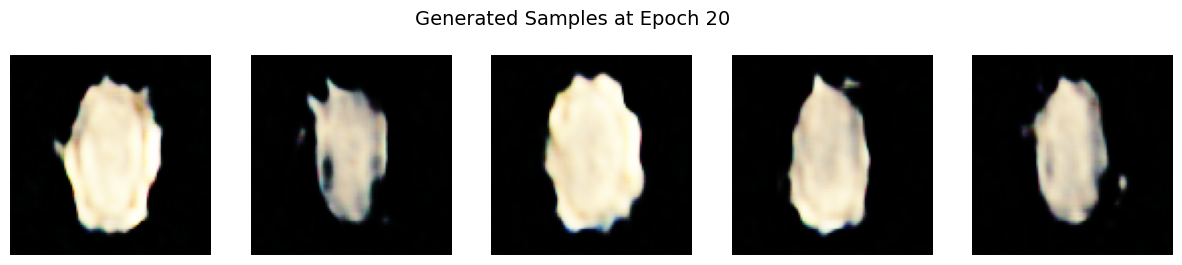

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 94ms/step - disc_loss: 1.3191 - gen_loss: 0.9137
Epoch 21/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2703 - gen_loss: 0.9205
Epoch 22/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2699 - gen_loss: 0.9149
Epoch 23/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.3076 - gen_loss: 0.9475
Epoch 24/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2550 - gen_loss: 0.9177
Epoch 25/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2736 - gen_loss: 0.9499
Epoch 26/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2607 - gen_loss: 0.9539
Epoch 27/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.2553 - gen_loss: 0.9363
Epoch 28/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 1.2986 - gen_loss: 0.9769
Epoch 29/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2672 - gen_loss: 0.9535
Epoch 30/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2382 - gen_loss: 0.9863
E

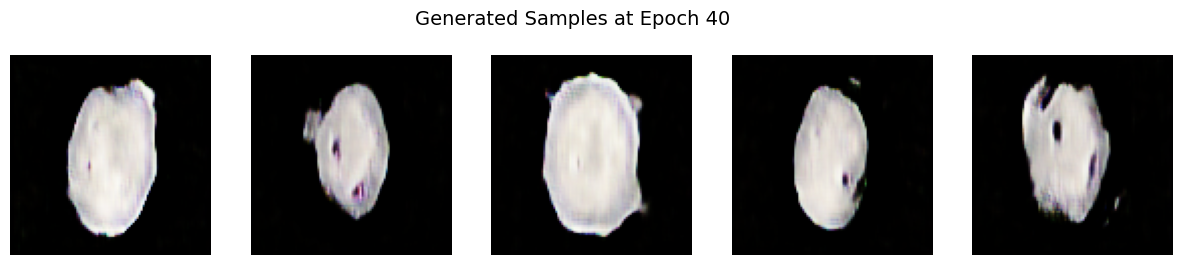

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 1.2996 - gen_loss: 0.9347
Epoch 41/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.2839 - gen_loss: 0.9194
Epoch 42/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.2787 - gen_loss: 0.9504
Epoch 43/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2657 - gen_loss: 0.9470
Epoch 44/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2915 - gen_loss: 0.9509
Epoch 45/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2988 - gen_loss: 0.9553
Epoch 46/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.3039 - gen_loss: 0.9392
Epoch 47/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2965 - gen_loss: 0.9352
Epoch 48/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.3104 - gen_loss: 0.8952
Epoch 49/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.3124 - gen_loss: 0.9572
Epoch 50/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.3043 - gen_loss: 0.9205
E

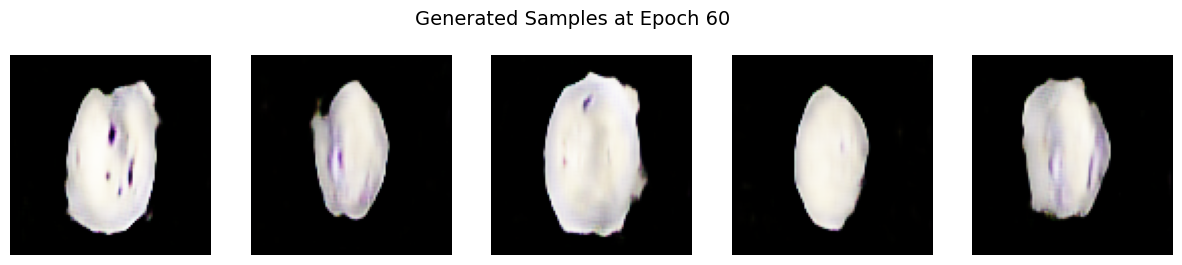

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 1.2803 - gen_loss: 0.9165
Epoch 61/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.3046 - gen_loss: 0.9151
Epoch 62/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.3043 - gen_loss: 0.9067
Epoch 63/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2895 - gen_loss: 0.9157
Epoch 64/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.3002 - gen_loss: 0.9082
Epoch 65/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.3050 - gen_loss: 0.9364
Epoch 66/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.3260 - gen_loss: 0.9186
Epoch 67/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.3051 - gen_loss: 0.8920
Epoch 68/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2878 - gen_loss: 0.8980
Epoch 69/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.3240 - gen_loss: 0.9235
Epoch 70/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.3393 - gen_loss: 0.9300
E

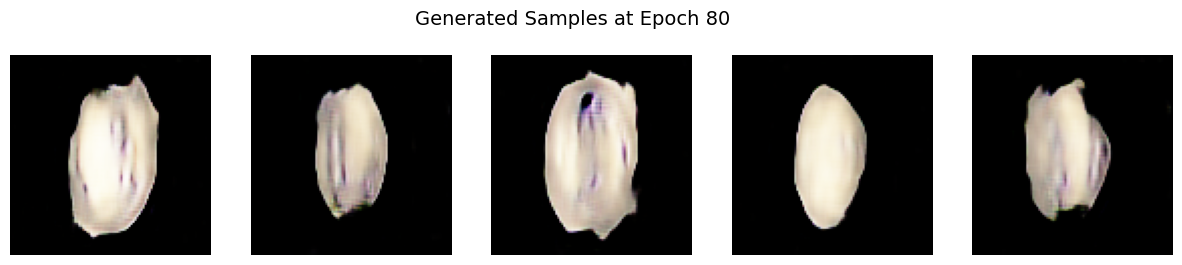

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - disc_loss: 1.2862 - gen_loss: 0.8854
Epoch 81/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2858 - gen_loss: 0.9260
Epoch 82/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.3061 - gen_loss: 0.8795
Epoch 83/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.3304 - gen_loss: 0.8858
Epoch 84/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.3035 - gen_loss: 0.9382
Epoch 85/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2773 - gen_loss: 0.9179
Epoch 86/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2956 - gen_loss: 0.9114
Epoch 87/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2772 - gen_loss: 0.9499
Epoch 88/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2833 - gen_loss: 0.9336
Epoch 89/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2939 - gen_loss: 0.8869
Epoch 90/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2776 - gen_loss: 0.9267
E

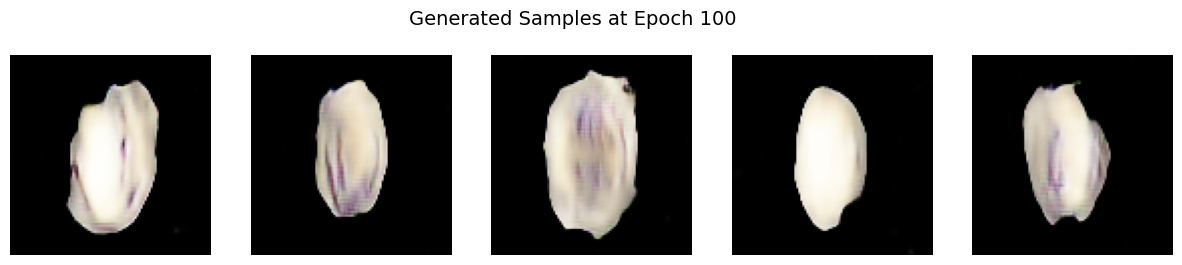

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 1.3108 - gen_loss: 1.0070
Epoch 101/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.3005 - gen_loss: 0.9084
Epoch 102/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2755 - gen_loss: 0.9568
Epoch 103/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2723 - gen_loss: 0.9376
Epoch 104/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2982 - gen_loss: 0.9627
Epoch 105/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2918 - gen_loss: 0.9341
Epoch 106/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2678 - gen_loss: 0.9408
Epoch 107/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2665 - gen_loss: 0.9499
Epoch 108/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2919 - gen_loss: 0.9451
Epoch 109/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.3106 - gen_loss: 1.0087
Epoch 110/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2736 - gen_loss

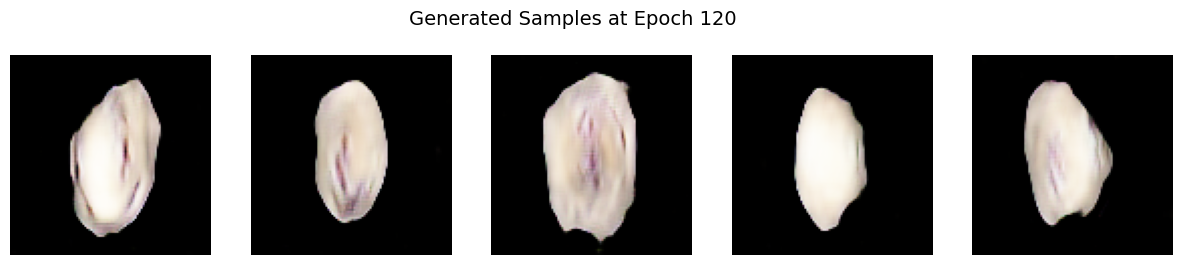

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 1.2635 - gen_loss: 0.9895
Epoch 121/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2571 - gen_loss: 0.9372
Epoch 122/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2571 - gen_loss: 0.9698
Epoch 123/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2413 - gen_loss: 0.9667
Epoch 124/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2620 - gen_loss: 0.9736
Epoch 125/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2385 - gen_loss: 0.9486
Epoch 126/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.2667 - gen_loss: 0.9564
Epoch 127/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - disc_loss: 1.2686 - gen_loss: 0.9814
Epoch 128/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.2514 - gen_loss: 0.9410
Epoch 129/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2544 - gen_loss: 0.9657
Epoch 130/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2352 - gen_loss

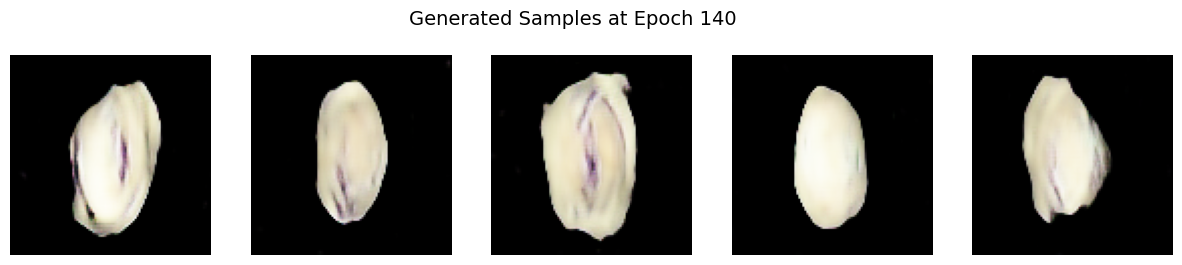

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - disc_loss: 1.2321 - gen_loss: 1.0156
Epoch 141/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2487 - gen_loss: 0.9809
Epoch 142/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2373 - gen_loss: 0.9890
Epoch 143/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2536 - gen_loss: 1.0042
Epoch 144/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2353 - gen_loss: 0.9771
Epoch 145/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2462 - gen_loss: 1.0059
Epoch 146/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2410 - gen_loss: 0.9827
Epoch 147/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2541 - gen_loss: 0.9647
Epoch 148/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2364 - gen_loss: 1.0275
Epoch 149/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2384 - gen_loss: 1.0139
Epoch 150/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2327 - gen_loss

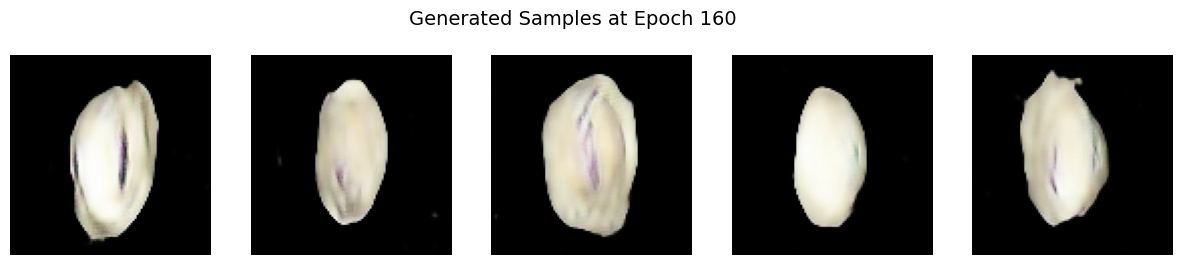

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 1.2436 - gen_loss: 1.0434
Epoch 161/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2167 - gen_loss: 1.0299
Epoch 162/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2412 - gen_loss: 1.0694
Epoch 163/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2289 - gen_loss: 1.0365
Epoch 164/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2366 - gen_loss: 1.0336
Epoch 165/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2285 - gen_loss: 0.9963
Epoch 166/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2117 - gen_loss: 1.0308
Epoch 167/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2162 - gen_loss: 1.0381
Epoch 168/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2280 - gen_loss: 1.0698
Epoch 169/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.1919 - gen_loss: 1.0315
Epoch 170/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.2143 - gen_loss

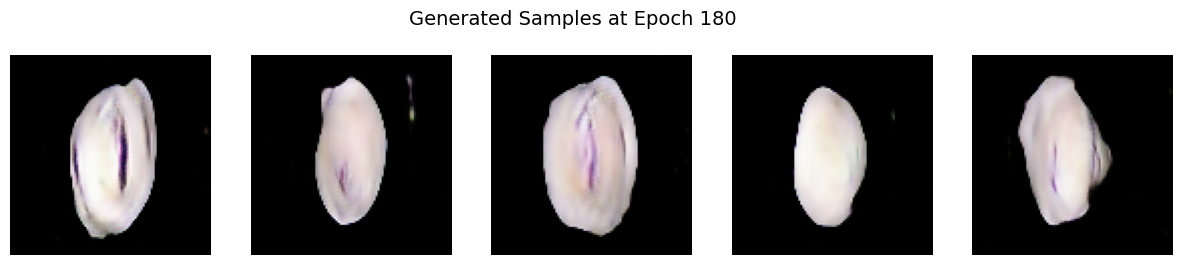

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 1.2163 - gen_loss: 1.0883
Epoch 181/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.1976 - gen_loss: 1.0420
Epoch 182/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.1943 - gen_loss: 1.0760
Epoch 183/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.1969 - gen_loss: 1.0660
Epoch 184/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.2090 - gen_loss: 1.0651
Epoch 185/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1851 - gen_loss: 1.0668
Epoch 186/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.1771 - gen_loss: 1.0656
Epoch 187/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1917 - gen_loss: 1.0550
Epoch 188/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.2367 - gen_loss: 1.0302
Epoch 189/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1918 - gen_loss: 1.0818
Epoch 190/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.1744 - gen_loss

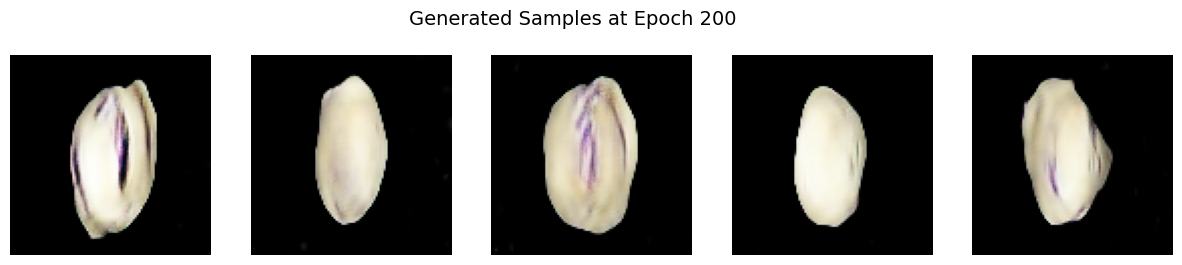

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - disc_loss: 1.1988 - gen_loss: 1.1062
Epoch 201/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1617 - gen_loss: 1.0925
Epoch 202/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1776 - gen_loss: 1.1337
Epoch 203/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1583 - gen_loss: 1.0408
Epoch 204/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1795 - gen_loss: 1.0747
Epoch 205/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1782 - gen_loss: 1.1005
Epoch 206/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.1921 - gen_loss: 1.1138
Epoch 207/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1938 - gen_loss: 1.1294
Epoch 208/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1717 - gen_loss: 1.1337
Epoch 209/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2250 - gen_loss: 1.1075
Epoch 210/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.1676 - gen_loss

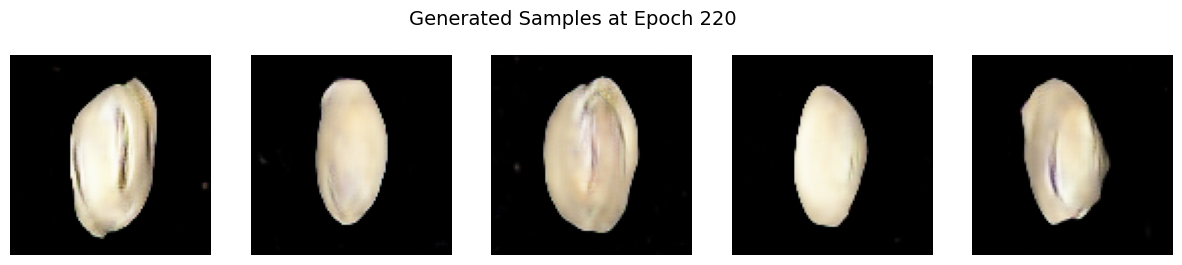

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - disc_loss: 1.1828 - gen_loss: 1.1353
Epoch 221/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1999 - gen_loss: 1.1370
Epoch 222/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.1367 - gen_loss: 1.1213
Epoch 223/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.1760 - gen_loss: 1.1340
Epoch 224/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.1532 - gen_loss: 1.1290
Epoch 225/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.2119 - gen_loss: 1.1171
Epoch 226/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1647 - gen_loss: 1.1191
Epoch 227/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1776 - gen_loss: 1.1421
Epoch 228/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1625 - gen_loss: 1.1271
Epoch 229/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.1425 - gen_loss: 1.1272
Epoch 230/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1547 - gen_loss

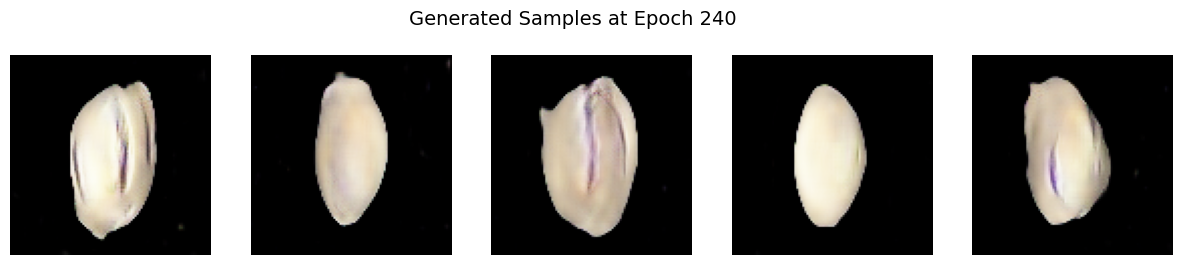

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 89ms/step - disc_loss: 1.1246 - gen_loss: 1.1933
Epoch 241/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1293 - gen_loss: 1.1721
Epoch 242/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.1293 - gen_loss: 1.1884
Epoch 243/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1438 - gen_loss: 1.1328
Epoch 244/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.1696 - gen_loss: 1.1428
Epoch 245/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1366 - gen_loss: 1.1928
Epoch 246/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.1403 - gen_loss: 1.1781
Epoch 247/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1480 - gen_loss: 1.1959
Epoch 248/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1219 - gen_loss: 1.1737
Epoch 249/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1280 - gen_loss: 1.1920
Epoch 250/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1227 - gen_loss

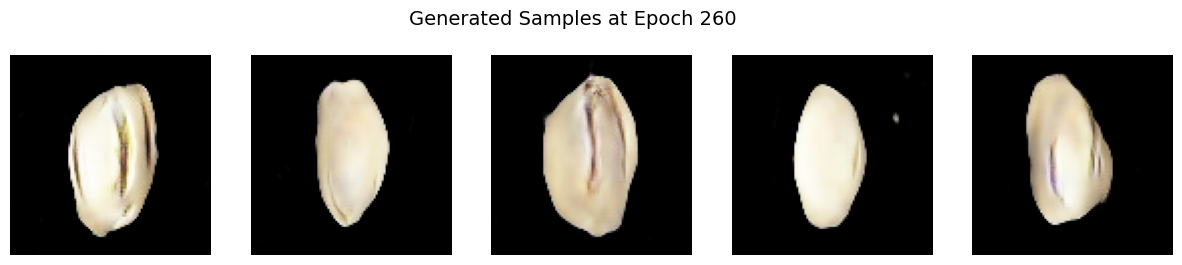

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - disc_loss: 1.1422 - gen_loss: 1.1826
Epoch 261/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.1322 - gen_loss: 1.1772
Epoch 262/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1290 - gen_loss: 1.2112
Epoch 263/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - disc_loss: 1.1370 - gen_loss: 1.2024
Epoch 264/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1412 - gen_loss: 1.1681
Epoch 265/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1027 - gen_loss: 1.1897
Epoch 266/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.1112 - gen_loss: 1.1856
Epoch 267/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1280 - gen_loss: 1.1850
Epoch 268/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.1230 - gen_loss: 1.1898
Epoch 269/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1151 - gen_loss: 1.2715
Epoch 270/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1171 - gen_loss

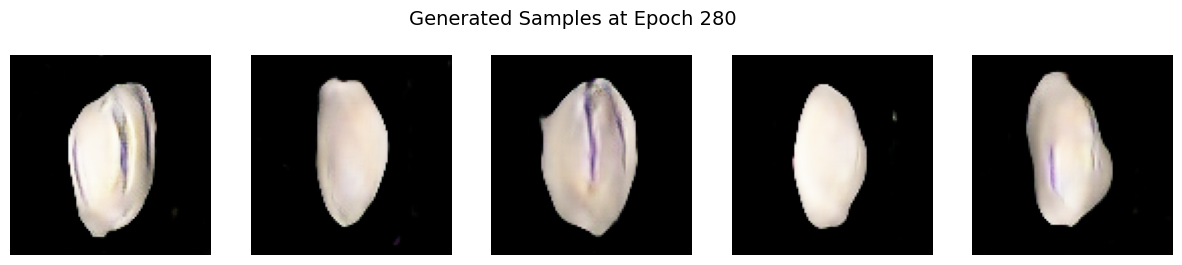

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - disc_loss: 1.1121 - gen_loss: 1.2044
Epoch 281/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1077 - gen_loss: 1.2257
Epoch 282/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1217 - gen_loss: 1.2056
Epoch 283/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0664 - gen_loss: 1.2394
Epoch 284/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.1095 - gen_loss: 1.3094
Epoch 285/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1493 - gen_loss: 1.2565
Epoch 286/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.1027 - gen_loss: 1.1683
Epoch 287/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1158 - gen_loss: 1.2351
Epoch 288/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.0983 - gen_loss: 1.2863
Epoch 289/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.1019 - gen_loss: 1.2510
Epoch 290/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step - disc_loss: 1.1087 - gen_loss

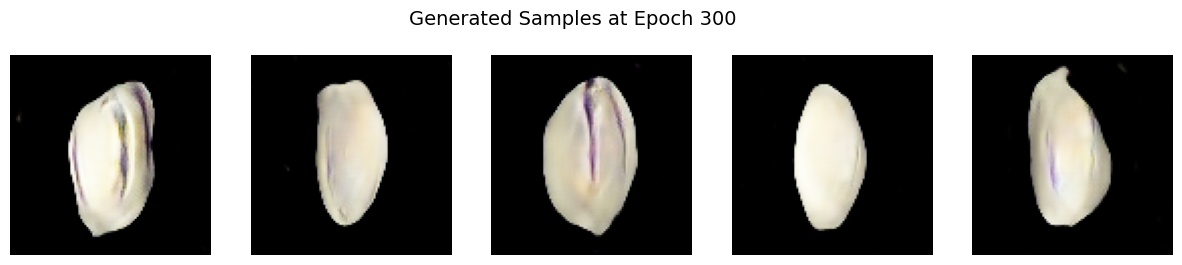

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 1.1149 - gen_loss: 1.2512
Epoch 301/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0789 - gen_loss: 1.2905
Epoch 302/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.0683 - gen_loss: 1.2622
Epoch 303/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0675 - gen_loss: 1.2800
Epoch 304/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.0815 - gen_loss: 1.3343
Epoch 305/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0755 - gen_loss: 1.2995
Epoch 306/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0829 - gen_loss: 1.2796
Epoch 307/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0803 - gen_loss: 1.2838
Epoch 308/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0669 - gen_loss: 1.2959
Epoch 309/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0826 - gen_loss: 1.2440
Epoch 310/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.0876 - gen_loss

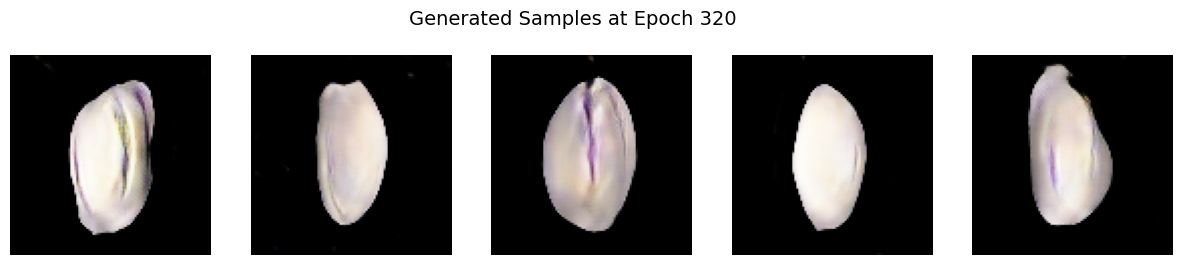

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 1.0661 - gen_loss: 1.3419
Epoch 321/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0616 - gen_loss: 1.3486
Epoch 322/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0747 - gen_loss: 1.2617
Epoch 323/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0513 - gen_loss: 1.3051
Epoch 324/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 1.0554 - gen_loss: 1.2471
Epoch 325/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.0731 - gen_loss: 1.2645
Epoch 326/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0832 - gen_loss: 1.3309
Epoch 327/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.0558 - gen_loss: 1.3066
Epoch 328/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0558 - gen_loss: 1.2902
Epoch 329/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0665 - gen_loss: 1.3100
Epoch 330/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0821 - gen_loss

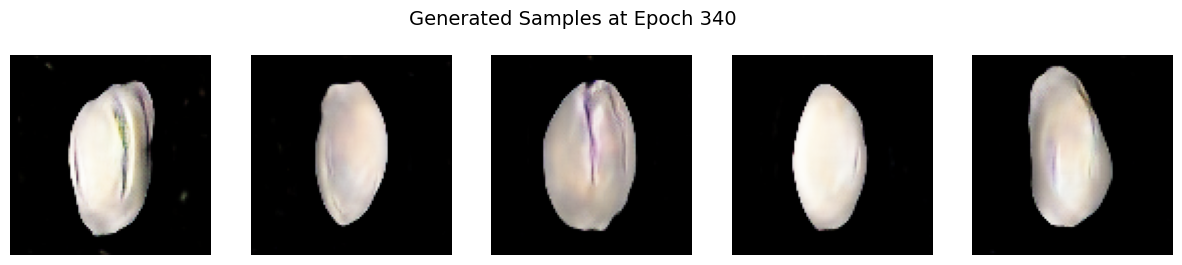

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - disc_loss: 1.0336 - gen_loss: 1.2971
Epoch 341/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0105 - gen_loss: 1.3379
Epoch 342/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0368 - gen_loss: 1.3244
Epoch 343/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.0855 - gen_loss: 1.3868
Epoch 344/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0431 - gen_loss: 1.3823
Epoch 345/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0521 - gen_loss: 1.2978
Epoch 346/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0483 - gen_loss: 1.2960
Epoch 347/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0512 - gen_loss: 1.3538
Epoch 348/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0386 - gen_loss: 1.3161
Epoch 349/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0587 - gen_loss: 1.3908
Epoch 350/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.0301 - gen_loss

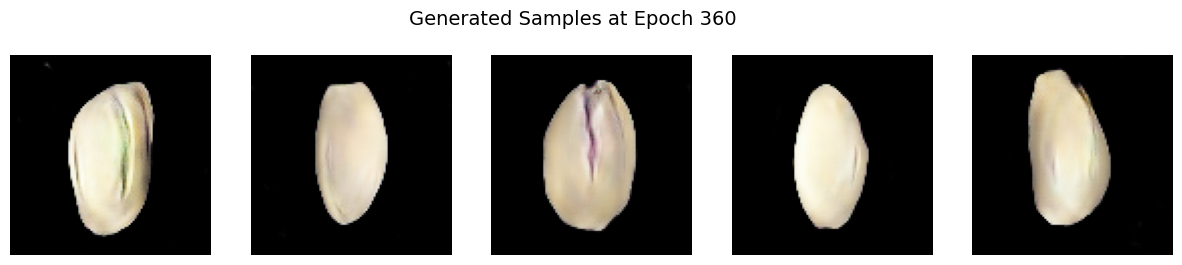

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 1.0484 - gen_loss: 1.4114
Epoch 361/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0777 - gen_loss: 1.3586
Epoch 362/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0463 - gen_loss: 1.3917
Epoch 363/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0417 - gen_loss: 1.3484
Epoch 364/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0478 - gen_loss: 1.3339
Epoch 365/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0111 - gen_loss: 1.3596
Epoch 366/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0436 - gen_loss: 1.3753
Epoch 367/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0656 - gen_loss: 1.3793
Epoch 368/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.0219 - gen_loss: 1.4433
Epoch 369/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0265 - gen_loss: 1.3768
Epoch 370/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0182 - gen_loss

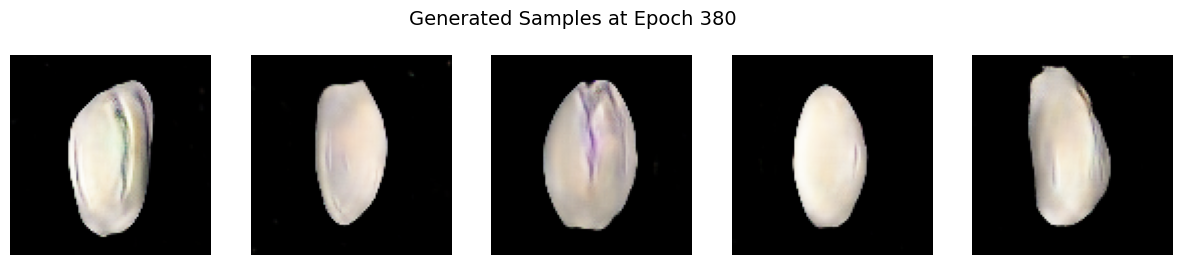

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 88ms/step - disc_loss: 1.0611 - gen_loss: 1.3086
Epoch 381/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 0.9996 - gen_loss: 1.3946
Epoch 382/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0260 - gen_loss: 1.3359
Epoch 383/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0275 - gen_loss: 1.3817
Epoch 384/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0278 - gen_loss: 1.3660
Epoch 385/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.0259 - gen_loss: 1.4378
Epoch 386/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0325 - gen_loss: 1.4216
Epoch 387/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0524 - gen_loss: 1.4003
Epoch 388/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0195 - gen_loss: 1.4211
Epoch 389/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0156 - gen_loss: 1.4700
Epoch 390/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0752 - gen_loss

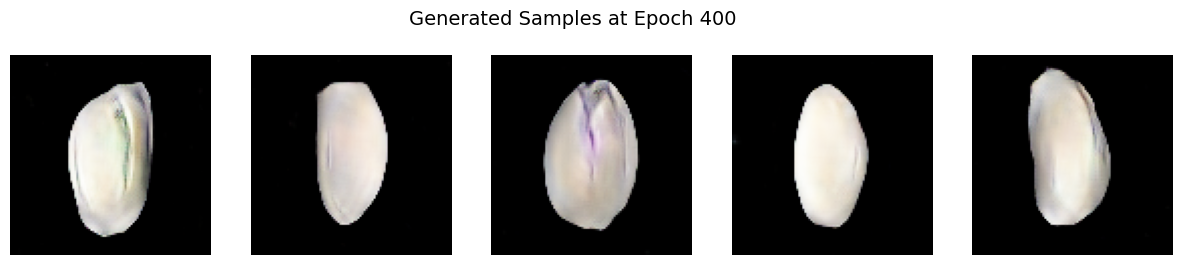

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 0.9960 - gen_loss: 1.4535
Epoch 401/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0579 - gen_loss: 1.4777
Epoch 402/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0263 - gen_loss: 1.4045
Epoch 403/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0097 - gen_loss: 1.4389
Epoch 404/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0572 - gen_loss: 1.3664
Epoch 405/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0467 - gen_loss: 1.3630
Epoch 406/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0223 - gen_loss: 1.4106
Epoch 407/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0019 - gen_loss: 1.3932
Epoch 408/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 0.9917 - gen_loss: 1.4260
Epoch 409/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0196 - gen_loss: 1.4936
Epoch 410/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - disc_loss: 1.0107 - gen_loss

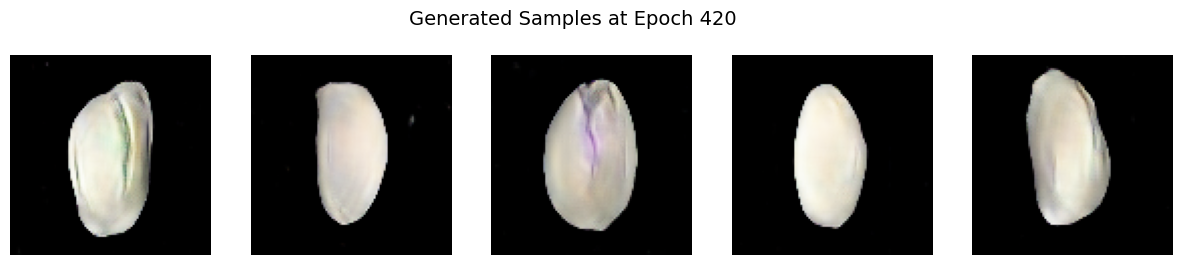

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - disc_loss: 0.9901 - gen_loss: 1.4305
Epoch 421/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0483 - gen_loss: 1.3957
Epoch 422/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.0114 - gen_loss: 1.4458
Epoch 423/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0165 - gen_loss: 1.3907
Epoch 424/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0027 - gen_loss: 1.4104
Epoch 425/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.0187 - gen_loss: 1.4459
Epoch 426/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 0.9792 - gen_loss: 1.4944
Epoch 427/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 0.9983 - gen_loss: 1.4362
Epoch 428/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 0.9938 - gen_loss: 1.4878
Epoch 429/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0258 - gen_loss: 1.4661
Epoch 430/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0396 - gen_loss

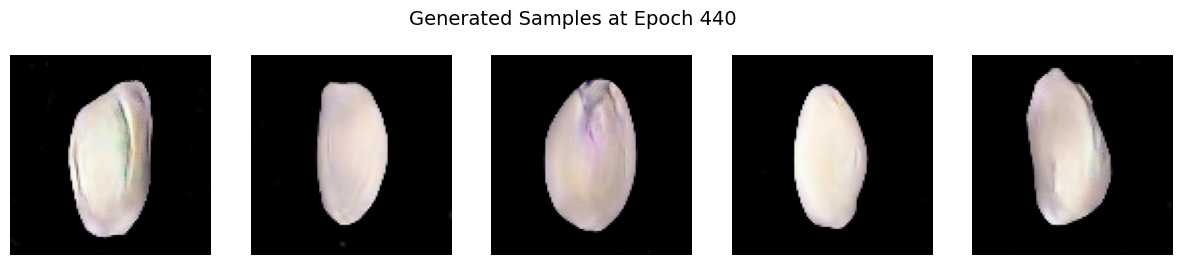

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 86ms/step - disc_loss: 1.0034 - gen_loss: 1.3911
Epoch 441/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0223 - gen_loss: 1.4008
Epoch 442/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 0.9811 - gen_loss: 1.4616
Epoch 443/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 0.9878 - gen_loss: 1.4958
Epoch 444/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0166 - gen_loss: 1.4360
Epoch 445/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0130 - gen_loss: 1.4981
Epoch 446/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 0.9990 - gen_loss: 1.4861
Epoch 447/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 0.9979 - gen_loss: 1.4931
Epoch 448/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0076 - gen_loss: 1.4108
Epoch 449/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0218 - gen_loss: 1.4642
Epoch 450/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 0.9976 - gen_loss

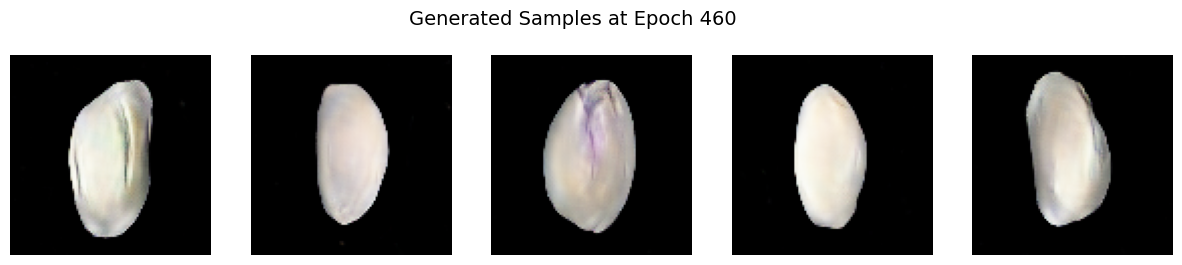

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 0.9929 - gen_loss: 1.5120
Epoch 461/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0057 - gen_loss: 1.5196
Epoch 462/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 0.9689 - gen_loss: 1.5118
Epoch 463/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0074 - gen_loss: 1.4922
Epoch 464/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 0.9780 - gen_loss: 1.4452
Epoch 465/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 0.9924 - gen_loss: 1.4826
Epoch 466/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 0.9870 - gen_loss: 1.4921
Epoch 467/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - disc_loss: 0.9878 - gen_loss: 1.4794
Epoch 468/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0423 - gen_loss: 1.4828
Epoch 469/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 1.0057 - gen_loss: 1.4556
Epoch 470/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 1.0217 - gen_loss

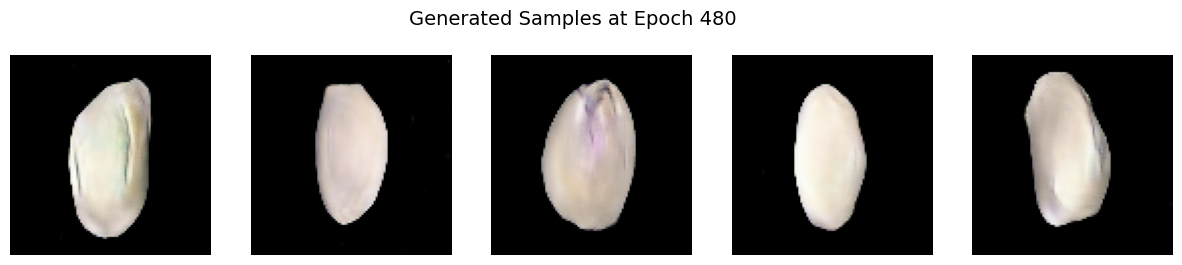

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 85ms/step - disc_loss: 1.0206 - gen_loss: 1.4570
Epoch 481/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0043 - gen_loss: 1.5331
Epoch 482/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 0.9621 - gen_loss: 1.4775
Epoch 483/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 0.9674 - gen_loss: 1.4814
Epoch 484/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 0.9950 - gen_loss: 1.5673
Epoch 485/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 0.9897 - gen_loss: 1.5118
Epoch 486/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 81ms/step - disc_loss: 1.0149 - gen_loss: 1.3971
Epoch 487/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 0.9716 - gen_loss: 1.4993
Epoch 488/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - disc_loss: 0.9576 - gen_loss: 1.5052
Epoch 489/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - disc_loss: 1.0106 - gen_loss: 1.4991
Epoch 490/500
34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 81ms/step - disc_loss: 0.9727 - gen_loss

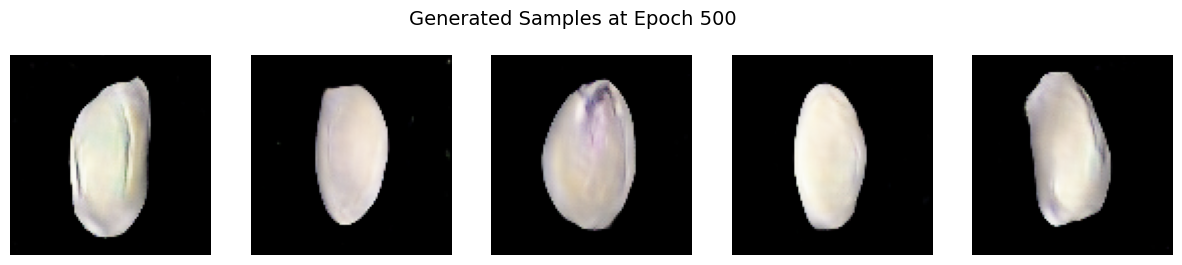

34/34 ━━━━━━━━━━━━━━━━━━━━ 5s 85ms/step - disc_loss: 0.9601 - gen_loss: 1.5599


In [ ]:
monitor = GANSnapshotCallback(num_samples=5, latent_dim=noise_dim, save_every=20)

gan.fit(
    real_images,
    epochs=500,
    batch_size=32,  # up sizing the batch size
    callbacks=[monitor]
)

## Evaluate Modify Model

In [ ]:
inception_model = InceptionV3(include_top=False, pooling='avg', input_shape=(299, 299, 3))

def calculate_fid(model, real_images, fake_images):
    real_resized = np.array([cv2.resize(img, (299, 299)) for img in real_images])
    fake_resized = np.array([cv2.resize(img, (299, 299)) for img in fake_images])

    real_resized = preprocess_input(real_resized.astype(np.float32))
    fake_resized = preprocess_input(fake_resized.astype(np.float32))

    act1 = model.predict(real_resized, batch_size=32, verbose=0)
    act2 = model.predict(fake_resized, batch_size=32, verbose=0)

    mu1, sigma1 = act1.mean(axis=0), np.cov(act1, rowvar=False)
    mu2, sigma2 = act2.mean(axis=0), np.cov(act2, rowvar=False)
    diff = mu1 - mu2
    covmean, _ = sqrtm(sigma1 @ sigma2, disp=False)

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    return diff @ diff + np.trace(sigma1 + sigma2 - 2 * covmean)

def evaluate_modified_fid(generator, real_images, noise_dim=100, sample_size=1000):
    real_images_sample = real_images[:sample_size].astype(np.float32)
    if real_images_sample.max() > 1.0:
        real_images_sample = real_images_sample / 255.0

    noise = np.random.normal(0, 1, (sample_size, noise_dim))
    gen_imgs = generator.predict(noise, batch_size=32, verbose=0)
    gen_imgs = 0.5 * gen_imgs + 0.5  # [-1,1] → [0,1]

    fid = calculate_fid(inception_model, real_images_sample, gen_imgs)
    print(f"FID Score (Modified Generator): {fid:.2f}")
    return fid

87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# call function evaluate
evaluate_modified_fid(generator, real_images)

FID Score (Modified Generator): 111.77


np.float64(111.77259567460209)

Modified 2 introduced an important change by reducing the discriminator’s learning rate to 0.0001 while keeping the generator’s learning rate at 0.0002. Additionally, the number of training epochs and the save interval were reduced. These changes made the discriminator less dominant, allowing the generator more opportunity to learn. This configuration resulted in the best FID score of 102, suggesting a better balance between the two models and an improvement in the quality of generated images.